In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt #garph representation
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/humairasiddique/climate-data-cvs/climate_data.cvs.csv


In [2]:
df = pd.read_csv("/kaggle/input/datasets/humairasiddique/climate-data-cvs/climate_data.cvs.csv")

In [3]:
df.head()

,ObjectId,Country,ISO2,ISO3,Indicator,Unit,Source,CTS Code,CTS Name,CTS Full Descriptor,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,1,"Afghanistan, Islamic Rep. of",AF,AFG,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate and Weath...",...,1.139,1.588,1.630,1.597,0.951,0.552,1.418,1.967,1.748,2.188
1,2,Africa,NaN,AFRTMP,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate and Weath...",...,1.195,1.385,1.158,1.150,1.290,1.177,1.400,1.014,1.485,1.750
2,3,Albania,AL,ALB,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate and Weath...",...,1.702,1.608,1.239,2.155,1.797,1.627,1.719,1.701,2.299,2.925
3,4,Algeria,DZ,DZA,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate and Weath...",...,1.134,1.761,1.506,1.203,1.240,2.006,2.424,1.804,2.303,2.824
4,5,American Samoa,AS,ASM,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate and Weath...",...,0.738,1.268,1.163,0.917,1.268,1.159,0.997,0.984,1.010,1.588


In [4]:
df.shape

(231, 74)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 231 entries, 0 to 230
Data columns (total 74 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ObjectId             231 non-null    int64  
 1   Country              231 non-null    object 
 2   ISO2                 224 non-null    object 
 3   ISO3                 231 non-null    object 
 4   Indicator            231 non-null    object 
 5   Unit                 231 non-null    object 
 6   Source               231 non-null    object 
 7   CTS Code             231 non-null    object 
 8   CTS Name             231 non-null    object 
 9   CTS Full Descriptor  231 non-null    object 
 10  1961                 194 non-null    float64
 11  1962                 196 non-null    float64
 12  1963                 195 non-null    float64
 13  1964                 194 non-null    float64
 14  1965                 194 non-null    float64
 15  1966                 198 non-null    flo

In [6]:
df.describe()

,ObjectId,1961,1962,1963,1964,1965,1966,1967,1968,1969,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
count,231.000000,194.000000,196.000000,195.000000,194.000000,194.000000,198.000000,195.000000,195.000000,195.000000,...,221.000000,221.000000,221.000000,220.000000,221.000000,219.000000,221.000000,221.000000,219.000000,219.000000
mean,116.129870,0.166804,-0.026770,-0.016667,-0.083521,-0.243753,0.107586,-0.107174,-0.214892,0.143046,...,1.289109,1.460900,1.293860,1.312955,1.449801,1.554845,1.349059,1.395140,1.685119,2.003201
std,67.052092,0.406646,0.352371,0.415444,0.304303,0.266752,0.415964,0.339612,0.346331,0.347087,...,0.496932,0.481958,0.411539,0.620499,0.463986,0.620921,0.477877,0.645096,0.593291,0.668942
min,1.000000,-0.664000,-1.364000,-2.244000,-0.869000,-1.064000,-2.357000,-1.052000,-3.250000,-1.740000,...,0.118000,0.337000,0.332000,0.261000,0.144000,0.301000,0.027000,0.074000,0.297000,0.035000
25%,58.500000,-0.088500,-0.176500,-0.211000,-0.248750,-0.389250,-0.035500,-0.281500,-0.342000,-0.024000,...,1.028000,1.164000,1.031000,0.876750,1.159000,1.158000,1.003000,0.901000,1.224000,1.542500
50%,116.000000,0.050000,-0.066500,-0.014000,-0.082500,-0.222500,0.118500,-0.131000,-0.179000,0.199000,...,1.231000,1.428000,1.256000,1.073000,1.372000,1.447000,1.278000,1.202000,1.611000,1.875000
75%,173.500000,0.354000,0.106000,0.221500,0.095500,-0.096000,0.301000,0.006500,-0.063000,0.360000,...,1.601000,1.705000,1.534000,1.840250,1.690000,1.841000,1.662000,1.911000,2.132000,2.423500
max,236.000000,1.895000,0.992000,1.190000,1.150000,0.869000,1.141000,1.138000,0.474000,0.943000,...,3.312000,5.326000,3.334000,4.064000,2.870000,3.684000,3.011000,3.511000,3.577000,3.689000


In [7]:
df.isnull().sum()

ObjectId      0
Country       0
ISO2          7
ISO3          0
Indicator     0
             ..
2020         12
2021         10
2022         10
2023         12
2024         12
Length: 74, dtype: int64

In [8]:
df.columns

Index(['ObjectId', 'Country', 'ISO2', 'ISO3', 'Indicator', 'Unit', 'Source',
       'CTS Code', 'CTS Name', 'CTS Full Descriptor', '1961', '1962', '1963',
       '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972',
       '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981',
       '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990',
       '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999',
       '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008',
       '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017',
       '2018', '2019', '2020', '2021', '2022', '2023', '2024'],
      dtype='object')

In [9]:
drop_columns = [
    "ObjectId",
    "ISO2",
    "ISO3",
    "Indicator",
    "Unit",
    "Source",
    "CTS Code",
    "CTS Name",
    "CTS Full Descriptor",
]

df = df.drop(columns=drop_columns)
df.head()

,Country,1961,1962,1963,1964,1965,1966,1967,1968,1969,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,"Afghanistan, Islamic Rep. of",-0.096,-0.143,0.848,-0.762,-0.233,0.239,-0.355,-0.402,-0.528,...,1.139,1.588,1.630,1.597,0.951,0.552,1.418,1.967,1.748,2.188
1,Africa,-0.015,-0.033,0.069,-0.149,-0.194,0.142,-0.212,-0.225,0.359,...,1.195,1.385,1.158,1.150,1.290,1.177,1.400,1.014,1.485,1.750
2,Albania,0.643,0.351,0.089,-0.154,-0.377,0.565,-0.071,0.085,-0.009,...,1.702,1.608,1.239,2.155,1.797,1.627,1.719,1.701,2.299,2.925
3,Algeria,0.154,0.105,0.072,0.248,-0.104,0.424,0.000,-0.065,0.275,...,1.134,1.761,1.506,1.203,1.240,2.006,2.424,1.804,2.303,2.824
4,American Samoa,0.075,-0.047,0.161,-0.146,-0.538,0.210,-0.339,-0.164,0.153,...,0.738,1.268,1.163,0.917,1.268,1.159,0.997,0.984,1.010,1.588


In [10]:
df.shape


(231, 65)

In [11]:
df.head()

,Country,1961,1962,1963,1964,1965,1966,1967,1968,1969,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,"Afghanistan, Islamic Rep. of",-0.096,-0.143,0.848,-0.762,-0.233,0.239,-0.355,-0.402,-0.528,...,1.139,1.588,1.630,1.597,0.951,0.552,1.418,1.967,1.748,2.188
1,Africa,-0.015,-0.033,0.069,-0.149,-0.194,0.142,-0.212,-0.225,0.359,...,1.195,1.385,1.158,1.150,1.290,1.177,1.400,1.014,1.485,1.750
2,Albania,0.643,0.351,0.089,-0.154,-0.377,0.565,-0.071,0.085,-0.009,...,1.702,1.608,1.239,2.155,1.797,1.627,1.719,1.701,2.299,2.925
3,Algeria,0.154,0.105,0.072,0.248,-0.104,0.424,0.000,-0.065,0.275,...,1.134,1.761,1.506,1.203,1.240,2.006,2.424,1.804,2.303,2.824
4,American Samoa,0.075,-0.047,0.161,-0.146,-0.538,0.210,-0.339,-0.164,0.153,...,0.738,1.268,1.163,0.917,1.268,1.159,0.997,0.984,1.010,1.588


In [12]:
df.isnull().sum()

Country     0
1961       37
1962       35
1963       36
1964       37
           ..
2020       12
2021       10
2022       10
2023       12
2024       12
Length: 65, dtype: int64

In [13]:
df = df.fillna(method="ffill")

In [14]:
print(df.duplicated().sum())

0


In [15]:
df = df.drop_duplicates()

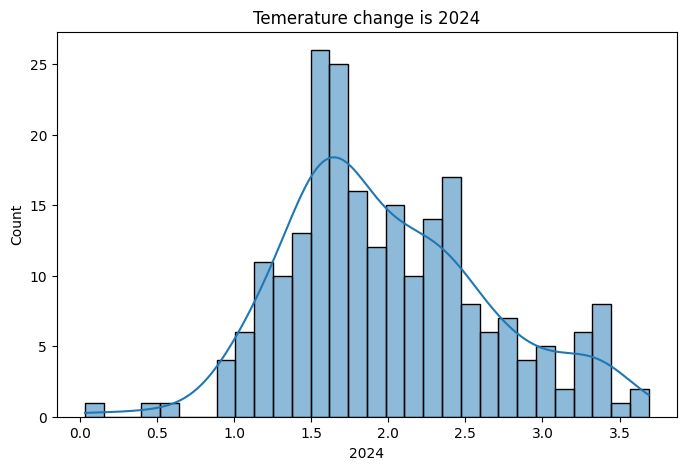

In [16]:
# temperature change in 2025 plot
plt.figure(figsize=(8,5))
sns.histplot(df["2024"], bins=30, kde=True)

plt.title("Temerature change is 2024")
plt.savefig("temperature_change_2024.png", dpi=300, bbox_inches="tight")

plt.show()

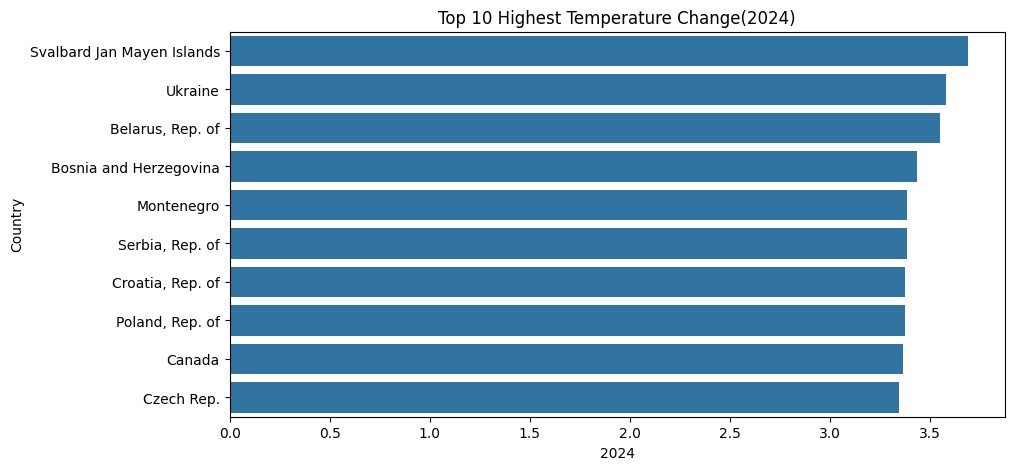

In [17]:
# top10 country highest temperature chat 
top10 = df.sort_values("2024", ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(data=top10, x="2024", y="Country")

plt.title("Top 10 Highest Temperature Change(2024)")
plt.savefig("top10 highest temperature_change_2024.png", dpi=300, bbox_inches="tight")

plt.show()

In [18]:
df_long = df.melt(
    id_vars="Country",
    var_name="Year",
    value_name="Temperature"
)
df_long.head()

,Country,Year,Temperature
0,"Afghanistan, Islamic Rep. of",1961,-0.096
1,Africa,1961,-0.015
2,Albania,1961,0.643
3,Algeria,1961,0.154
4,American Samoa,1961,0.075


In [19]:
df_long.shape

(14784, 3)

In [20]:
df_long["Year"] = df_long["Year"].astype(int)

In [21]:
df_long.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14784 entries, 0 to 14783
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Country      14784 non-null  object 
 1   Year         14784 non-null  int64  
 2   Temperature  14784 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 346.6+ KB


In [22]:
df.isnull().sum()

Country    0
1961       0
1962       0
1963       0
1964       0
          ..
2020       0
2021       0
2022       0
2023       0
2024       0
Length: 65, dtype: int64

In [23]:
df_long.dropna(inplace=True)

In [24]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df_long["Country"] = encoder.fit_transform(df_long["Country"])

In [25]:
x = df_long[["Country", "Year"]]
y = df_long["Temperature"]


In [26]:
# train and test model 
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)


In [27]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
model.fit(x_train, y_train)

RandomForestRegressor(random_state=42)

In [28]:
y_pred = model.predict(x_test)

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R² Score:", r2_score(y_test, y_pred))

MAE: 0.31236111261413596
RMSE: 0.42930814365624437
R² Score: 0.6203179780643029


In [30]:
# features and importance
importance = pd.DataFrame({
    "Feature": x.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

importance

,Feature,Importance
1,Year,0.661056
0,Country,0.338944


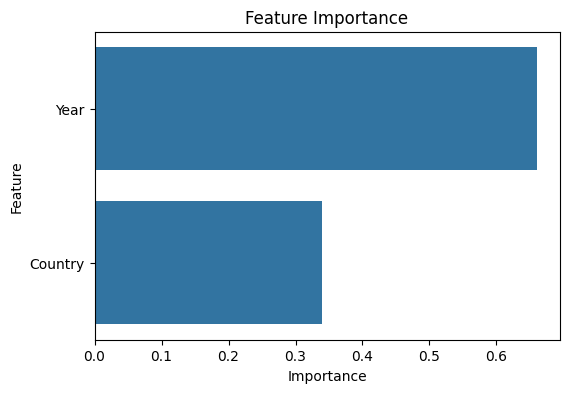

In [31]:
plt.figure(figsize=(6,4))

sns.barplot(data=importance,
            x="Importance",
            y="Feature")

plt.title("Feature Importance")
plt.savefig("feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

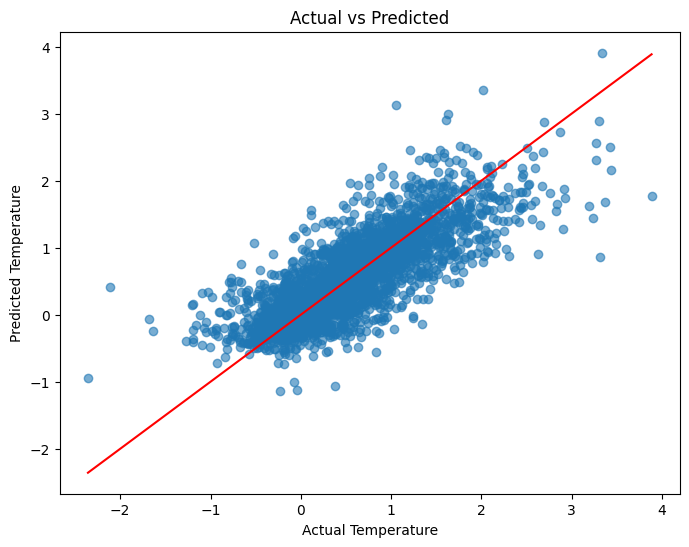

In [32]:
# actucal and predictional temperature representation
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.xlabel("Actual Temperature")
plt.ylabel("Predicted Temperature")
plt.title("Actual vs Predicted")
plt.savefig("ActuAL and Prediction Temperature.png", dpi=300, bbox_inches="tight")
plt.show()

In [33]:
import joblib

joblib.dump(model, "climate_model.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [34]:
df_long.to_csv("cleaned_climate_data.csv", index=False)

In [35]:
#Different model comparison
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [36]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

In [37]:
results = []

for name, model in models.items():

    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append([name, mae, rmse, r2])

comparison = pd.DataFrame(
    results,
    columns=["Model", "MAE", "RMSE", "R2 Score"]
)

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.358589,0.478066,0.529178
1,Decision Tree,0.375238,0.541286,0.396419
2,Random Forest,0.312361,0.429308,0.620318
3,Gradient Boosting,0.316288,0.425597,0.626853


In [38]:
comparison.sort_values(by="R2 Score", ascending=False)

,Model,MAE,RMSE,R2 Score
3,Gradient Boosting,0.316288,0.425597,0.626853
2,Random Forest,0.312361,0.429308,0.620318
0,Linear Regression,0.358589,0.478066,0.529178
1,Decision Tree,0.375238,0.541286,0.396419


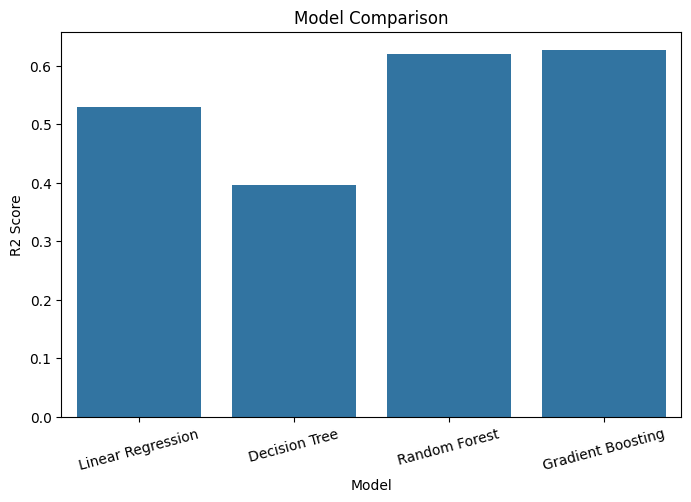

In [39]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="R2 Score"
)

plt.title("Model Comparison")
plt.xticks(rotation=15)
plt.savefig("model_comparison.png", dpi=300, bbox_inches="tight")

plt.show()

In [40]:
best_model = RandomForestRegressor(random_state=42)

best_model.fit(x_train, y_train)

RandomForestRegressor(random_state=42)

# Conclusion

In this project, multiple regression models were trained and evaluated to predict climate temperature changes.

The models compared were:
- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor
- Gradient Boosting Regressor

Among all the models, **Random Forest Regressor** achieved the highest R² Score, making it the best-performing model for this dataset.

Final Model Performance:
- MAE: 0.312
- RMSE: 0.429
- R² Score: 0.620

Therefore, the Random Forest Regressor was selected as the final model because it provided the most accurate predictions.

In [41]:
import joblib

joblib.dump(model, "climate_temperature_model.pkl")

print("Model saved successfully!")

Model saved successfully!
